# Transmission Grid Synthesis from pypowsybl-Supported Formats

This notebook demonstrates how to use **pypowsybl** as the entry point for
**transmission** grid synthesis using the **IEEE-118 bus** system. We load
the reference grid from both the built-in pypowsybl network and from a
**CGMES** file, then run the full CLC synthesis pipeline.

**Sections:**
1. Loading the IEEE-118 reference grid (built-in + CGMES)
2. Transmission synthesis (Mode I — reference-based)
3. Analysis & comparison
4. Export to multiple formats (CGMES, XIIDM, JSON)
5. Power-flow validation

In [1]:
import os
import tempfile
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import pypowsybl as ppl

## 1. Loading the IEEE-118 Reference Grid

We load the IEEE-118 bus system in two ways:
1. **Built-in** — `ppl.network.create_ieee118()` (pypowsybl's bundled test networks)
2. **From CGMES file** — save to CGMES, then reload via `load_grid()`

pypowsybl supports many industry-standard formats:
CGMES, XIIDM, MATPOWER, IEEE-CDF, PSS/E, UCTE, BIIDM, JIIDM, POWER-FACTORY.

In [2]:
# Load IEEE-118 bus from built-in pypowsybl
net_ppl = ppl.network.create_ieee118()

print(f"IEEE-118 bus network (built-in):")
print(f"  Buses:        {len(net_ppl.get_buses())}")
print(f"  Lines:        {len(net_ppl.get_lines())}")
print(f"  Transformers: {len(net_ppl.get_2_windings_transformers())}")
print(f"  Generators:   {len(net_ppl.get_generators())}")
print(f"  Loads:        {len(net_ppl.get_loads())}")

# Voltage levels
vl = net_ppl.get_voltage_levels()
print(f"\nVoltage levels:")
for vl_id, row in vl.iterrows():
    print(f"  {vl_id}: {row['nominal_v']:.1f} kV")

IEEE-118 bus network (built-in):
  Buses:        118
  Lines:        177
  Transformers: 9
  Generators:   54
  Loads:        91

Voltage levels:
  VL1: 138.0 kV
  VL2: 138.0 kV
  VL3: 138.0 kV
  VL4: 138.0 kV
  VL5: 138.0 kV
  VL6: 138.0 kV
  VL7: 138.0 kV
  VL8: 345.0 kV
  VL9: 345.0 kV
  VL10: 345.0 kV
  VL11: 138.0 kV
  VL12: 138.0 kV
  VL13: 138.0 kV
  VL14: 138.0 kV
  VL15: 138.0 kV
  VL16: 138.0 kV
  VL17: 138.0 kV
  VL18: 138.0 kV
  VL19: 138.0 kV
  VL20: 138.0 kV
  VL21: 138.0 kV
  VL22: 138.0 kV
  VL23: 138.0 kV
  VL24: 138.0 kV
  VL25: 138.0 kV
  VL26: 345.0 kV
  VL27: 138.0 kV
  VL28: 138.0 kV
  VL29: 138.0 kV
  VL30: 345.0 kV
  VL31: 138.0 kV
  VL32: 138.0 kV
  VL33: 138.0 kV
  VL34: 138.0 kV
  VL35: 138.0 kV
  VL36: 138.0 kV
  VL37: 138.0 kV
  VL38: 345.0 kV
  VL39: 138.0 kV
  VL40: 138.0 kV
  VL41: 138.0 kV
  VL42: 138.0 kV
  VL43: 138.0 kV
  VL44: 138.0 kV
  VL45: 138.0 kV
  VL46: 138.0 kV
  VL47: 138.0 kV
  VL48: 138.0 kV
  VL49: 138.0 kV
  VL50: 138.0 kV
  VL51: 138.0

### 1.1. Converting pypowsybl → NetworkX

`pypowsybl_to_nx()` extracts buses, lines, transformers, loads, and generators
from a pypowsybl Network object into a NetworkX graph with all the attributes
needed by the synthesis pipeline.

In [3]:
from powergrid_synth import pypowsybl_to_nx, load_grid

# Convert built-in pypowsybl Network → NetworkX graph
graph_ref = pypowsybl_to_nx(net_ppl)

print(f"Nodes: {graph_ref.number_of_nodes()}")
print(f"Edges: {graph_ref.number_of_edges()}")
print(f"Voltage level map: {graph_ref.graph['base_kv_map']}")

# Bus type breakdown
bus_types = Counter(d["bus_type"] for _, d in graph_ref.nodes(data=True))
print(f"Bus types: {dict(bus_types)}")

Nodes: 118
Edges: 179
Voltage level map: {0: 345.0, 1: 161.0, 2: 138.0}
Bus types: {'Gen': 54, 'Load': 54, 'Conn': 10}


In [4]:
# Inspect node attributes
print("Sample node attributes:")
for n, d in list(graph_ref.nodes(data=True))[:3]:
    print(f"  {n}: {d}")

print("\nSample edge attributes:")
for u, v, d in list(graph_ref.edges(data=True))[:3]:
    print(f"  {u} -- {v}: {d}")

Sample node attributes:
  VL1_0: {'voltage_level': 2, 'vn_kv': 138.0, 'bus_type': 'Gen', 'pl': 51.0, 'ql': 27.0, 'pg': 0.0, 'pg_max': 9999.0}
  VL2_0: {'voltage_level': 2, 'vn_kv': 138.0, 'bus_type': 'Load', 'pl': 20.0, 'ql': 9.0}
  VL3_0: {'voltage_level': 2, 'vn_kv': 138.0, 'bus_type': 'Load', 'pl': 39.0, 'ql': 10.0}

Sample edge attributes:
  VL1_0 -- VL2_0: {'type': 'line', 'r': 5.770332, 'x': 19.024956000000003, 'b': 0.0001333753413148498, 'g': 0.0}
  VL1_0 -- VL3_0: {'type': 'line', 'r': 2.456676, 'x': 8.074656000000001, 'b': 5.6815795001050204e-05, 'g': 0.0}
  VL2_0 -- VL12_0: {'type': 'line', 'r': 3.561228, 'x': 11.731104, 'b': 8.254568367989918e-05, 'g': 0.0}


### 1.2. Loading from CGMES file

We save the IEEE-118 to **CGMES** format (the Common Grid Model Exchange Standard
used by European TSOs), then reload it via `load_grid()` to demonstrate the
CGMES import → NetworkX conversion round-trip.

In [5]:
# Save IEEE-118 to CGMES format
cgmes_dir = os.path.join("output", "ieee118_cgmes_ref")
os.makedirs(cgmes_dir, exist_ok=True)
net_ppl.save(cgmes_dir, format="CGMES")

cgmes_files = [f for f in os.listdir(cgmes_dir) if f.endswith(".xml")]
print(f"CGMES files saved to {cgmes_dir}/:")
for f in sorted(cgmes_files):
    fpath = os.path.join(cgmes_dir, f)
    print(f"  {f}  ({os.path.getsize(fpath):,} bytes)")

# Reload from CGMES via load_grid
graph_from_cgmes = load_grid(cgmes_dir)
print(f"\nReloaded from CGMES: {graph_from_cgmes.number_of_nodes()} nodes, "
      f"{graph_from_cgmes.number_of_edges()} edges")
print(f"Built-in reference:  {graph_ref.number_of_nodes()} nodes, "
      f"{graph_ref.number_of_edges()} edges")
assert graph_from_cgmes.number_of_nodes() == graph_ref.number_of_nodes(), \
    "Node count mismatch!"
print("CGMES round-trip OK ✓")

CGMES files saved to output/ieee118_cgmes_ref/:
  ieee118_cgmes_ref_EQ.xml  (400,756 bytes)
  ieee118_cgmes_ref_SSH.xml  (152,757 bytes)
  ieee118_cgmes_ref_SV.xml  (173,663 bytes)
  ieee118_cgmes_ref_TP.xml  (104,432 bytes)

Reloaded from CGMES: 118 nodes, 179 edges
Built-in reference:  118 nodes, 179 edges
CGMES round-trip OK ✓


### Note: IEEE-118 differences between pypowsybl and pandapower

The IEEE-118 bus system in pypowsybl and pandapower are not identical.
There are small differences in the number of generators, load values, and
voltage level assignments between the two implementations. This is a known
discrepancy arising from different source data and modelling conventions
used by each library. As a result, the synthetic grids generated from a
pypowsybl-loaded reference may differ slightly from those generated from
a pandapower-loaded reference of the same IEEE test case.

## 2. Transmission Synthesis (Mode I — Reference-Based)

We extract topology parameters from the pypowsybl-loaded reference graph,
then generate a synthetic clone using the CLC pipeline.

In [6]:
from powergrid_synth import (
    PowerGridGenerator,
    BusTypeAllocator,
    CapacityAllocator,
    LoadAllocator,
    GenerationDispatcher,
    TransmissionLineAllocator,
    extract_topology_params_from_graph,
    TransmissionGrid,
)

# Extract topology characteristics
params = extract_topology_params_from_graph(graph_ref)

print("Extracted topology parameters:")
for key, val in params.items():
    if isinstance(val, dict):
        for k2, v2 in val.items():
            print(f"  {key}[{k2}]: {v2}")
    else:
        print(f"  {key}: {val}")

Extracting topology parameters...
Extracted topology parameters:
  degrees_by_level: [[3, 1, 2, 2, 1, 2, 2, 1, 1, 2, 3], [0], [2, 2, 3, 2, 4, 2, 2, 4, 7, 2, 2, 5, 2, 5, 2, 4, 2, 2, 2, 4, 3, 2, 4, 2, 2, 3, 5, 2, 4, 2, 2, 5, 2, 4, 2, 3, 2, 2, 3, 3, 3, 2, 9, 2, 3, 2, 2, 5, 3, 5, 2, 2, 5, 3, 3, 4, 3, 2, 5, 5, 3, 2, 1, 2, 5, 2, 6, 2, 2, 6, 3, 3, 2, 5, 1, 2, 4, 2, 2, 6, 2, 5, 2, 5, 2, 2, 2, 8, 2, 2, 4, 3, 5, 3, 2, 2, 2, 4, 1, 1, 2, 2, 2, 0, 1, 2]]
  diameters_by_level: [7, 0, 17]
  transformer_degrees[(0, 2)]: ([1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])
  transformer_degrees[(1, 2)]: ([1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [7]:
# Generate synthetic topology
gen = PowerGridGenerator(seed=42)
graph_syn = gen.generate_grid(
    degrees_by_level=params["degrees_by_level"],
    diameters_by_level=params["diameters_by_level"],
    transformer_degrees=params["transformer_degrees"],
    keep_lcc=True,
)

print(f"Reference:  {graph_ref.number_of_nodes()} nodes, {graph_ref.number_of_edges()} edges")
print(f"Synthetic:  {graph_syn.number_of_nodes()} nodes, {graph_syn.number_of_edges()} edges")

--- Starting Generation for 3 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 14, Edges: 10
Generating Level 1...
  -> Level 1 Complete. Nodes: 1, Edges: 0
Generating Level 2...
  -> Level 2 Complete. Nodes: 117, Edges: 157
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 2
  -> Connecting Level 1 <-> Level 2
Filtering for Largest Connected Component (LCC)...
  -> Kept 118 nodes (removed 14 isolated nodes)
Reference:  118 nodes, 179 edges
Synthetic:  118 nodes, 175 edges


In [8]:
# Assign bus types
allocator = BusTypeAllocator(graph_syn)
bus_types = allocator.allocate()
nx.set_node_attributes(graph_syn, bus_types, name="bus_type")

bt_counts = Counter(bus_types.values())
print(f"Bus types: {dict(bt_counts)}")

Starting Bus Type Allocation (N=118, M=175)...
  Target Entropy Score (W*): 2.6094, Std Dev: 0.0413
  Iter 0: Best Error = 0.010322
  Converged at iteration 3. Error: 0.000020 < Criteria: 0.000041
Bus types: {'Gen': 28, 'Load': 62, 'Conn': 28}


In [9]:
# Allocate generation, load, dispatch, and transmission lines
base_kv_map = graph_ref.graph.get("base_kv_map", {0: 110.0})

CapacityAllocator(graph_syn).allocate()
LoadAllocator(graph_syn).allocate(loading_level="H")
GenerationDispatcher(graph_syn).dispatch()
TransmissionLineAllocator(graph_syn).allocate()

print("Full synthesis pipeline complete ✓")
print(f"Synthetic grid: {graph_syn.number_of_nodes()} nodes, {graph_syn.number_of_edges()} edges")

Allocating Capacity for 28 generators.
Total System Capacity Target: 10631.90 MW using Reference System 1
Allocating Loads for 62 load buses.
Total System Load Target: 6664.80 MW (Level: D)
Full synthesis pipeline complete ✓
Synthetic grid: 118 nodes, 175 edges


## 3. Analysis & Comparison

Compare the synthetic grid with the pypowsybl-loaded reference.

In [10]:
from powergrid_synth import GraphComparator, GridVisualizer

comparator = GraphComparator(graph_syn, graph_ref)

# Compare degree distributions per voltage level
df = comparator.compare_degree_distributions()
df


DEGREE DISTRIBUTION COMPARISON  (KS & Relative Hausdorff)
  Level KS Statistic RH Distance
Level 0       0.1364      0.3333
Level 2       0.2075      0.1818



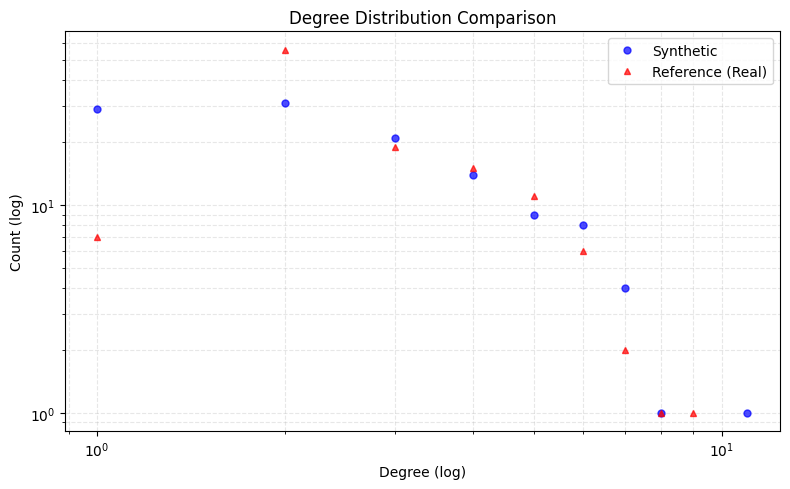

<Figure size 640x480 with 0 Axes>

In [11]:
# Degree distribution comparison
comparator.plot_degree_comparison(log_scale=True)
plt.tight_layout()
plt.show()

Calculating layout 'kamada_kawai'...


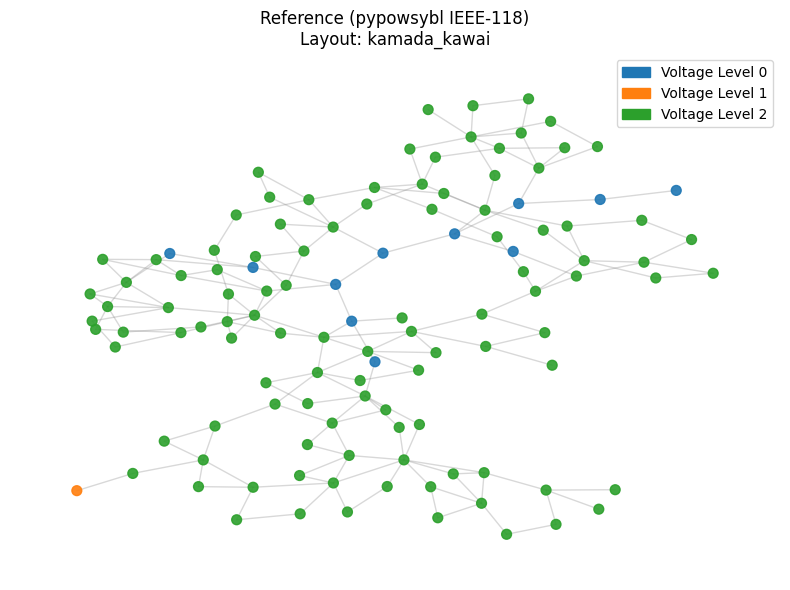

Calculating layout 'kamada_kawai'...


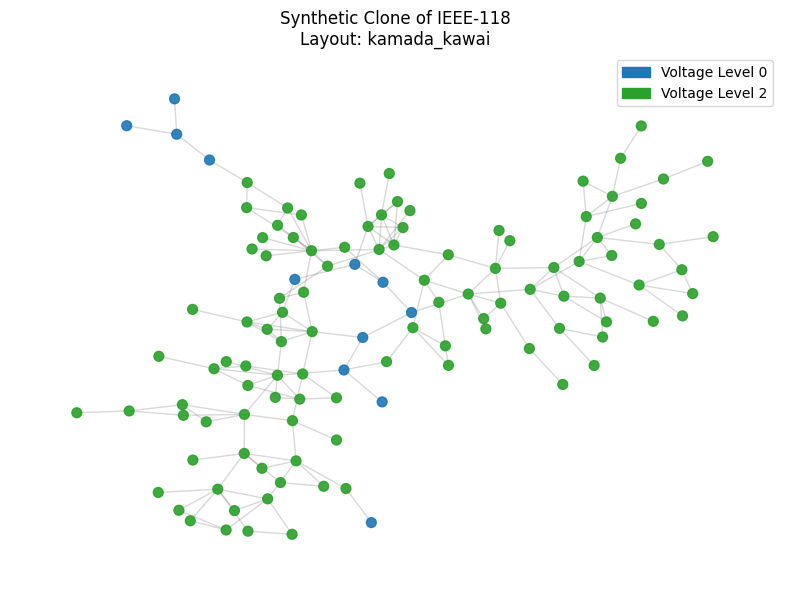

In [12]:
# Visualize both grids
viz = GridVisualizer()

viz.plot_grid(graph_ref, title="Reference (pypowsybl IEEE-118)", figsize=(8, 6))
plt.show()

viz.plot_grid(graph_syn, title="Synthetic Clone of IEEE-118", figsize=(8, 6))
plt.show()

## 4. Export to Multiple Formats

The synthetic grid can be exported back to any pypowsybl-supported format.

In [13]:
from powergrid_synth import GridExporter, nx_to_pandapower

base_kv_list = graph_ref.graph.get("base_kv_map", {0: 110.0})
exporter = GridExporter(graph_syn, base_kv_map=base_kv_list)

os.makedirs("output", exist_ok=True)

# Export to CGMES (pypowsybl) — create target directory first
cgmes_out = os.path.join("output", "ieee118_syn_cgmes")
os.makedirs(cgmes_out, exist_ok=True)
exporter.to_cgmes(cgmes_out)
print(f"CGMES files: {sorted(os.listdir(cgmes_out))}")

# Export to XIIDM (pypowsybl)
exporter.to_pypowsybl("output/ieee118_syn.xiidm", format="XIIDM")

# Export to JSON (pandapower)
exporter.to_json("output/ieee118_syn.json")

# Verify: reload the CGMES export
graph_reloaded = load_grid(cgmes_out)
print(f"\nReloaded from CGMES: {graph_reloaded.number_of_nodes()} nodes, "
      f"{graph_reloaded.number_of_edges()} edges")
print("Export → reload cycle OK ✓")

-> pypowsybl CGMES export: output/ieee118_syn_cgmes
CGMES files: ['ieee118_syn_cgmes_EQ.xml', 'ieee118_syn_cgmes_SSH.xml', 'ieee118_syn_cgmes_SV.xml', 'ieee118_syn_cgmes_TP.xml']
-> pypowsybl XIIDM export: output/ieee118_syn.xiidm
-> pandapower JSON export: output/ieee118_syn.json

Reloaded from CGMES: 118 nodes, 175 edges
Export → reload cycle OK ✓


## 5. Power-Flow Validation

Validate the synthetic transmission grid using pandapower DC and pypowsybl AC load-flow solvers.

In [14]:
from powergrid_synth import pandapower_to_pypowsybl, nx_to_pandapower
import pandapower as pp

# Convert synthetic transmission grid to pandapower
net_syn_pp = nx_to_pandapower(graph_syn, base_kv_map=base_kv_list)
print(f"pandapower network: {len(net_syn_pp.bus)} buses, {len(net_syn_pp.line)} lines, "
      f"{len(net_syn_pp.trafo)} trafos")

# Run DC power flow via pandapower
try:
    pp.rundcpp(net_syn_pp)
    print(f"\nDC power flow converged ✓")
    print(f"  Max bus voltage angle: {net_syn_pp.res_bus.va_degree.max():.2f}°")
    print(f"  Min bus voltage angle: {net_syn_pp.res_bus.va_degree.min():.2f}°")
except Exception as e:
    print(f"DC power flow failed: {e}")

pandapower network: 118 buses, 166 lines, 9 trafos

DC power flow converged ✓
  Max bus voltage angle: 0.00°
  Min bus voltage angle: 0.00°


In [15]:
# Convert to pypowsybl and run AC load flow
try:
    net_syn_ppl = pandapower_to_pypowsybl(net_syn_pp)
    results = ppl.loadflow.run_ac(net_syn_ppl)
    print("pypowsybl AC load flow results:")
    for r in results:
        print(f"  Component {r.connected_component_num}: status={r.status.name}, "
              f"iterations={r.iteration_count}")
except Exception as e:
    print(f"pypowsybl AC load flow: {e}")

pypowsybl AC load flow results:
  Component 0: status=CONVERGED, iterations=1


## Summary

This notebook demonstrated the full **import → synthesize → export** round-trip
for transmission grid synthesis using the IEEE-118 bus system:

1. **Loading the reference grid** — from both the built-in pypowsybl network and from CGMES files
2. **Transmission synthesis** — CLC pipeline using topology extracted from the pypowsybl-loaded reference
3. **Analysis & comparison** — degree distributions, grid visualization
4. **Export** — to CGMES, XIIDM, and JSON formats via `GridExporter`
5. **Power-flow validation** — DC (pandapower) and AC (pypowsybl) load-flow solvers

All pypowsybl-supported formats can be used as input:
CGMES, XIIDM, IEEE-CDF, MATPOWER, PSS/E, UCTE, BIIDM, JIIDM, POWER-FACTORY.